<a href="https://colab.research.google.com/github/WuDianQiBian/ml-course/blob/master/notebooks/ch02_python_basics/sec07_numpy_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

NumPy简介4 - Reduction 与数组重组
==============


<p align="center">
  <img src="https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/assets/banner.jpg" alt="五点七边 Logo" width="900"/>
</p>

In [ ]:
# @title 辅助函数：读取、展示图片、视频
import numpy as np
from PIL import Image
from IPython.display import display, Image as IPythonImage
import imageio
import io

# 下载素材
!wget -q -nc --directory-prefix=downloads https://raw.githubusercontent.com/WuDianQiBian/ml-course/master/notebooks/ch02_python_basics/assets/Clark.jpg


def read_image(path="downloads/Clark.jpg"):
    img = Image.open(path)
    return np.asarray(img).copy()


def display_image(img):
    display(Image.fromarray(img))


def display_video_as_gif(video, fps=20, loop=0):
    buf = io.BytesIO()
    imageio.mimsave(buf, video, format="gif", fps=fps, loop=loop)
    display(IPythonImage(data=buf.getvalue(), format="gif"))

# 第十章：Reduction 与 Axis


## 10.1 向量的 Softmax

softmax 的定义如下：

$$
\mathrm{softmax}(x_i) = \frac{e^{x_i}}{\sum_{j=1}^{n} e^{x_j}}
$$

它有几个重要性质：

- 每个元素都落在 `(0, 1)` 区间内
- 所有元素之和等于 `1`
- 不改变输入向量中各元素的相对大小关系
- 常用来把一个向量映射为概率分布


In [ ]:
x = np.array([1.2, 0.3, -0.7], dtype=np.float32)

exp_x = np.exp(x)
softmax_x = exp_x / np.sum(exp_x)

print(f"{softmax_x=}")

## 10.2 二维数组的 Softmax

现在我们把问题升级到二维数组。这里约定：
- 每一行是一个向量
- softmax 需要对每一行独立计算
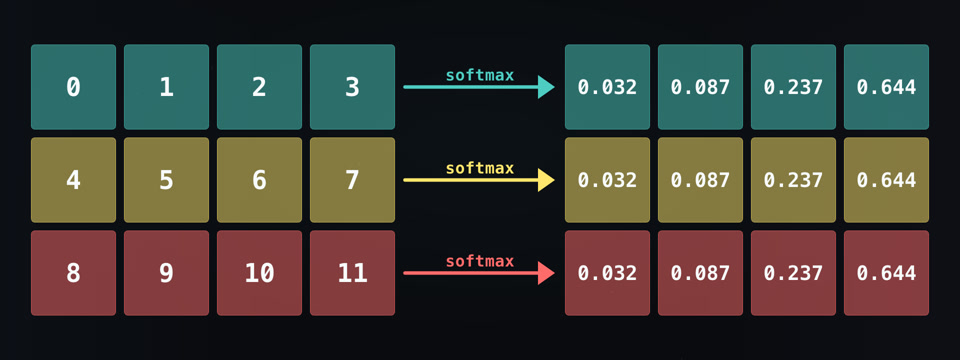


In [ ]:
X = np.array([
    [0, 1, 2, 3],
    [4, 5, 6, 7],
    [8, 9, 10, 11],
], dtype=np.float32)
print(f"{X=}")
print(f"{X.shape=}")

### 10.2.1 for 循环版本：单独处理每一行


In [ ]:
out = np.zeros_like(X)

for i in range(X.shape[0]):  # 单独处理每一行
    exp_row = np.exp(X[i])
    out[i] = exp_row / np.sum(exp_row)

print(out)

**注释:**
在使用 NumPy 的时候，尽量避免 Python 层面的 `for` 循环，是一个非常重要的优化原则。


### 10.2.2 一次性处理整个二维数组

In [ ]:
exp_X = np.exp(X)                # 逐元素求exp()
row_sum = np.sum(exp_X, axis=1)  # 逐行求和

print(f"{exp_X.shape=}")
print(f"{row_sum.shape=}")

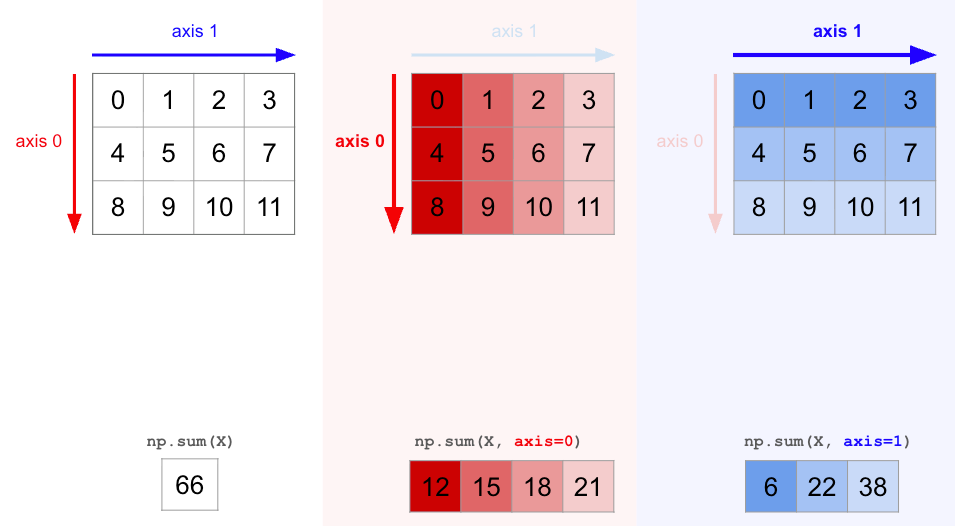
</details>

**axis表示:** 在哪一个维度上做汇总，即压缩掉这个维度。

In [ ]:
row_sum = row_sum.reshape(X.shape[0], 1)
softmax_X = exp_X / row_sum

print(softmax_X)

### 10.2.3 `keepdims`：让代码更自然

如果不想手动 reshape，可以直接在 reduction 时保留维度。


In [ ]:
row_sum = np.sum(exp_X, axis=1, keepdims=True)
softmax_X = exp_X / row_sum

print(f"{row_sum.shape=}")
print(softmax_X)

## 10.3 三维数组的 Softmax

假设 `X` 的 shape 是 `(B, T, D)`，我们约定最后一维 `D` 是向量，softmax 要在这一维上进行。


### 10.3.1 笨但好理解的方法：reshape 成二维


In [ ]:
X = np.arange(2 * 3 * 4, dtype=np.float32).reshape(2, 3, 4) - 12
B, T, D = X.shape

X_2d = X.reshape(B * T, D)
exp_X_2d = np.exp(X_2d)
sum_X_2d = np.sum(exp_X_2d, axis=1, keepdims=True)
softmax_X_via_reshape = (exp_X_2d / sum_X_2d).reshape(B, T, D)

print(f"{X.shape=}")
print(f"{softmax_X_via_reshape.shape=}")
print(softmax_X_via_reshape)

### 10.3.2 其实没必要 reshape


In [ ]:
def softmax_batch(X):
    exp_X = np.exp(X)
    sum_X = np.sum(exp_X, axis=-1, keepdims=True)
    return exp_X / sum_X

softmax_X = softmax_batch(X)
print(softmax_X)
print('allclose =', np.allclose(softmax_X, softmax_X_via_reshape))
print('last-dim sums =')
print(np.sum(softmax_X, axis=-1))

## 10.4 三维 Softmax：for 循环 vs 批处理

这里继续用 softmax 比较 Python 层循环和批处理写法的差异。


In [ ]:
# 手动循环版 softmax
def softmax_using_loop(X):
    output = np.zeros_like(X, dtype=np.float32)
    for i in range(X.shape[0]):
        for j in range(X.shape[1]):
            x_slice = X[i, j, :]
            exp_x_slice = np.array([np.exp(val) for val in x_slice])
            sum_exp_x_slice = np.sum(exp_x_slice)
            softmax_slice = exp_x_slice / sum_exp_x_slice
            output[i, j, :] = softmax_slice
    return output

In [ ]:
X_large = np.random.rand(100, 100, 100).astype(np.float32)

# 批处理版 softmax 性能测试:
%timeit softmax_batch(X_large)
# 循环版 softmax 性能测试:
%timeit softmax_using_loop(X_large)

## 10.5 其他常用的 Reduction（了解即可）


In [ ]:
X = np.array([
    [0, 1, 2, 3],
    [4, 5, 6, 7],
    [8, 9, 10, 11],
], dtype=np.float32)

np.mean(X, axis=0)  # 每列求平均

In [ ]:
np.std(X, axis=0)  # 每列的标准差

In [ ]:
np.max(X, axis=1)  # 每行求最大值

In [ ]:
np.argmax(X, axis=1)  # 每行最大值的下标

**常见 reduction 函数：**
| 类别 | 常见 reduction 函数 | 说明 |
| ---- | ------------------ | ---- |
| **求和 / 求积** | `sum`, `prod` | 沿某个 axis 做加和 / 连乘 |
| **平均与统计量** | `mean`, `median` | 均值 / 中位数 |
| | `std`, `var` | 标准差 / 方差 |
| **极值与位置** | `min`, `max` | 最小值 / 最大值 |
| | `argmin`, `argmax` | 最小值 / 最大值对应的下标 |
| | `ptp` | 最大值减最小值（peak-to-peak） |
| **逻辑汇总** | `all`, `any` | 是否全部为真 / 是否至少一个为真 |
| **计数** | `count_nonzero` | 统计非零元素个数 |
| **分位数** | `quantile`, `percentile` | 分位数 / 百分位数 |
| **NaN 友好版本** | `nansum`, `nanmean`, `nanstd` | 忽略 `NaN` 再做 reduction |
| | `nanmin`, `nanmax`, `nanargmin`, `nanargmax` | 忽略 `NaN` 的极值 / 极值位置 |

这些函数大多支持 `axis` 参数，很多也支持 `keepdims=True`。


# 第十一章：数组重组（concat / stack / split）


## 11.1 np.concatenate：拼接，但不增加维度


In [ ]:
# 横向拼接图片：

img = read_image()

bright = np.clip(img + 80.0, 0, 255).astype(np.uint8)
dark   = np.clip(img - 80.0, 0, 255).astype(np.uint8)
high_c = np.clip((img - 128.0) * 1.5 + 128, 0, 255).astype(np.uint8)
low_c  = np.clip((img - 128.0) * 0.5 + 128, 0, 255).astype(np.uint8)

hcat = np.concatenate([img, bright, dark, high_c, low_c], axis=1)
display_image(hcat)

核心直觉：
- `concatenate` 只会让某个 `axis` 方向变长（拼接）
- 不会新增维度


In [ ]:
# 纵向拼接图片：

# 白色间隔条（横条）
spacer_v = np.full((16, img.shape[1], img.shape[2]), 255, dtype=img.dtype)

img3 = img // 2  # 图片变暗

vcat = np.concatenate([img, spacer_v, img3], axis=0)
display_image(vcat)

In [ ]:
# concat 失败示例：

try:
    bad = np.zeros((512, 800, 3), dtype=img.dtype)  # 与 (600, 800, 3) 在 axis!=0 处不匹配
    np.concatenate([img, bad], axis=1)
except ValueError as e:
    print('ValueError:', e)

**concatenate 的一般规则：**
- 输入数组的 `ndim` 必须相同
- 除了 `axis` 指定维度外，其余维度必须完全一致
- 输出 `ndim` 不变，只有 `shape[axis]` 会变大

## 11.2 np.stack：新增一个维度再拼接


In [ ]:
# 图片 stack 成视频

video = np.stack([img, bright, dark, high_c, low_c], axis=0)

display_video_as_gif(video, fps=1, loop=0)

In [ ]:
print(f"{img.shape      = }")
print(f"{bright.shape   = }")
print(f"{dark.shape     = }")
print(f"{high_c.shape   = }")
print(f"{low_c.shape    = }")
print(f"{video.shape    = }")

## 11.3 concatenate + stack 组合


In [ ]:
frames = []

# 构造黑色单色图像 (模仿 img 中的 R 通道构建)
black = np.zeros_like(img[..., 0])                        # (H, W)

for frame in [img, bright, dark, high_c, low_c]:
    # 用 stack 构造 R / G / B 单色图像
    R = np.stack([frame[:, :, 0], black, black], axis=2)  # (H, W) * 3 ⮕ (H, W, 3)
    G = np.stack([black, frame[:, :, 1], black], axis=2)  # (H, W) * 3 ⮕ (H, W, 3)
    B = np.stack([black, black, frame[:, :, 2]], axis=2)  # (H, W) * 3 ⮕ (H, W, 3)

    # 用 concatenate 将它们在水平方向拼接
    frame_hcat = np.concatenate([frame, R, G, B], axis=1) # (H, W, 3) * 4 ⮕ (H, 4*W, 3)
    frames.append(frame_hcat)

# 在最外层，用 stack 组织成一个视频
video = np.stack(frames, axis=0)                          # (H, 4*W, 3) * N ⮕ (N, H, 4*W, 3)

display_video_as_gif(video, fps=1)

## 11.4 np.split：把一个数组拆开


In [ ]:
# 按切点拆分：

H, W, C = img.shape
i1 = 100
i2 = 250

p1, p2, p3 = np.split(img, [i1, i2], axis=0)

print('p1:', p1.shape)  # img[:i1,   ...]
display_image(p1)
print('p2:', p2.shape)  # img[i1:i2, ...]
display_image(p2)
print('p3:', p3.shape)  # img[i2:,   ...]
display_image(p3)

In [ ]:
# 等分成 N 份：

try:
    parts = np.split(img, 4, axis=0)
    for i, p in enumerate(parts):
        print(f'parts[{i}] shape:', p.shape)
        display_image(p)
except ValueError as e:
    print('ValueError:', e)
    print('提示：np.split(x, 4, axis=0) 要求 x.shape[0] 能被 4 整除。')

## 11.5 其他常见数组重组函数（了解即可）

| 函数 | 作用（简写说明） |
| --- | --- |
| **`array_split`** | 拆分数组；比 `split` 更宽松，不要求整除 |
| **`hsplit` / `vsplit` / `dsplit`** | 沿固定方向拆分；是 `split` 的便捷写法 |
| **`hstack` / `vstack` / `dstack`** | 沿固定方向拼接；比 `concatenate` / `stack` 更偏快捷接口 |
| **`column_stack`** | 把 1D 数组按列拼成 2D；2D 输入则按列并排 |
| **`row_stack`** | `vstack` 的别名；当前 NumPy 中已弃用，不建议新代码使用 |
| **`block`** | 用嵌套列表按块状方式组装数组 |
| **`tile`** | 重复整个数组的结构 |
| **`repeat`** | 重复数组中的元素 |
| **`unstack`** | 沿某个轴拆成一个 tuple；可视为 `stack` 的反操作（NumPy 2.1+） |

# 思考题

单位向量的内积，可以用来衡量相似度：

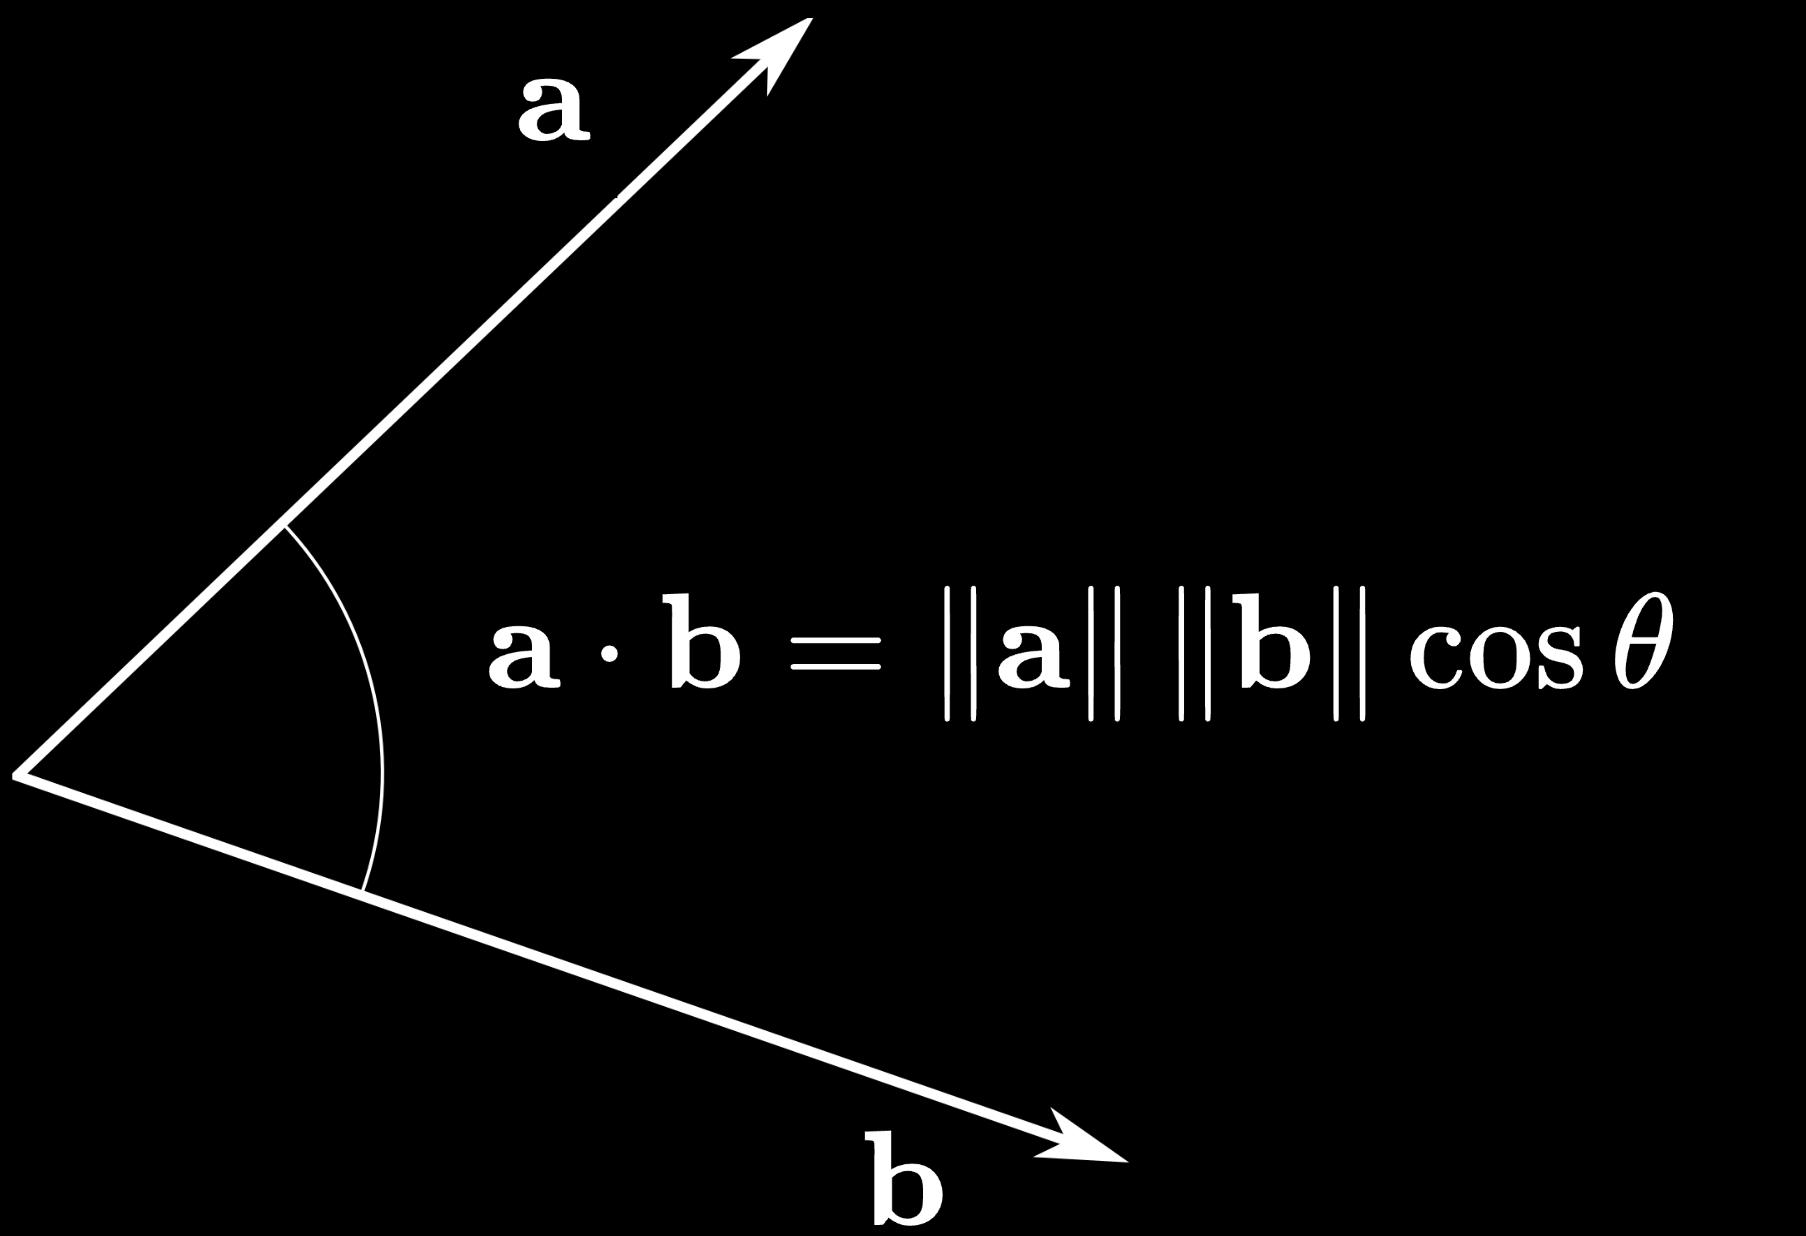

如何给 `N` 个 `D` 维的单位向量，计算彼此间的相似度，画出 `N x N` 的热力图?

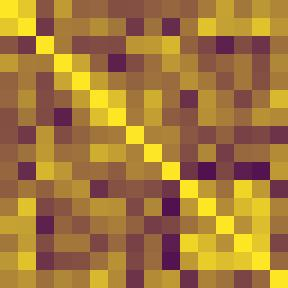


**提示:**
* 是否可以快速计算 N 个向量之间的内积 (点乘) 呢?
* 两个单位向量内积值是否有上下界?
* 先画出每个小块 (某对向量的相似度), 是否会更容易呢?
* 参考下面代码生成单位向量:

In [ ]:
np.random.seed(0)
N, D = 16, 8  # 16 个单位向量，每个单位向量有 8 维
X = np.random.randn(N, D).astype(np.float32)
X = X / np.linalg.norm(X, axis=1, keepdims=True)